In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

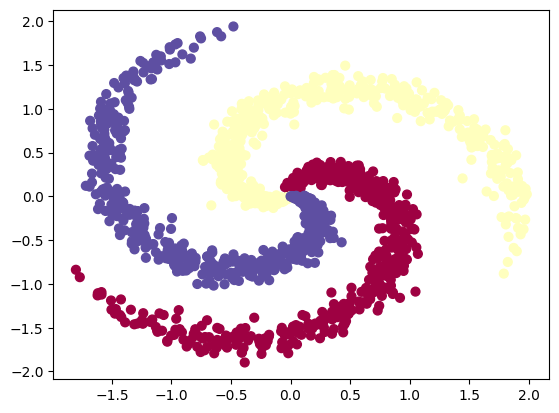

In [81]:
# https://cs231n.github.io/neural-networks-case-study/

N = 500 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes

X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels

for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,2,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [82]:
X = pd.DataFrame(X, columns=['x1', 'x2'])
X.head(3)

,x1,x2
0,-0.000000,0.000000
1,-0.000021,0.004008
2,0.000766,0.007979


In [83]:
y = pd.Series(y)
y.head(3)

0    0
1    0
2    0
dtype: uint8

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(1200, 300, 1200, 300)

In [58]:
y_train.head(3)

382     0
538     1
1493    2
dtype: uint8

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
def scale_data(data: pd.DataFrame) -> pd.DataFrame:
  return pd.DataFrame(scaler.fit_transform(data), columns=data.columns, index=data.index)
def scale_target(target) -> pd.Series:
  return pd.Series(scaler.fit_transform(target))

X_train_scaled, X_test_scaled = scale_data(X_train), scale_data(X_test)
# y_train_scaled, y_test_scaled = scale_target(y_train), scale_target(y_test)

In [60]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.50      0.47      0.49       104
           1       0.48      0.63      0.55        86
           2       0.52      0.43      0.47       110

    accuracy                           0.50       300
   macro avg       0.50      0.51      0.50       300
weighted avg       0.50      0.50      0.50       300

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       104
           1       0.97      0.99      0.98        86
           2       0.98      0.90      0.94       110

    accuracy                           0.94       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.94      0.94       300



## with transformed data

In [106]:
N = 500 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes

X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels

for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,2,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
X = pd.DataFrame(X, columns=['x1', 'x2'])
y = pd.Series(y)

In [109]:
import math

theta = 45
X["x1"] = (np.sin(math.radians(theta)) * X['x1']) + (np.cos(math.radians(theta)) * X['x2'])
X["x2"] = (np.sin(math.radians(theta)) * X['x2']) + (np.cos(math.radians(theta)) * X['x1'])

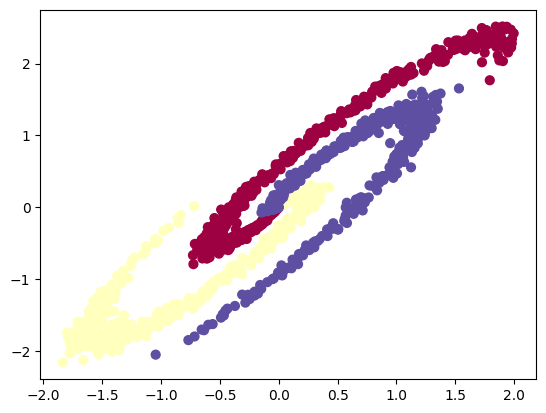

In [110]:
# lets visualize the data:
plt.scatter(X['x1'], X['x2'], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()